**Prologue**: As I transition from data analysis to data science, my goal is to explore numerous methods to garner the best results. In this endeavor, I seek to absorb as much knowledge as possible. Given the multitude of methods and options, there may be gaps or inaccuracies in my approach. I would greatly value your review of my work, including any identified shortcomings, potential improvements, or areas of success. Your insights are crucial for my development. I am grateful for your time. Rather than progress through simple, incremental steps, I thrive on tackling complex challenges directly—even manufacturing them if none exist.

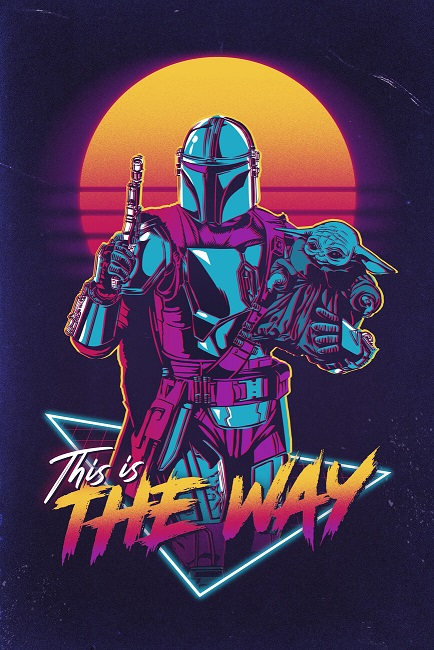

This study adheres to my learning philosophy. While I have reached a tentative conclusion, I acknowledge there could be overlooked errors. If my work piques your interest, your feedback would be greatly appreciated. I anticipate potential errors in areas such as:

- Data leak
- Code clutter and repetitive situations
- Logical errors
- Mismanaging or inadequately managing the process

If you see any errors or areas for improvement related to these, I've already told you what to do :D

<h1><center><font size="6">Credit Card Fraud Detection Predictive Models</font></center></h1>


- <a href='#1'>Introduction</a>  
- <a href='#2'>EDA</a>  
- <a href='#3'>Data Preprocessing</a>
- <a href='#4'>Sampling</a>
- <a href='#5'>Model Evaluation</a>  
- <a href='#6'>Performance Analysis</a>
- <a href='#7'>Conclusions</a>

# <a id="1">Introduction</a>  

The **dataset** in question captures a snapshot of credit card transactions over a period of two days, specifically from cardholders in **Europe**. Within this collection, there are a total of **284,807** individual transactions, of which **492** have been classified as **fraudulent**. It is important to note the disproportionate distribution between the fraudulent transactions and the legitimate ones, underscoring the dataset's significant **imbalance**. To be precise, the fraudulent transactions, or the 'positive class', constitute a mere **0.172%** of the entire dataset. This stark imbalance poses a unique challenge for any analytical model aiming to identify fraudulent activity, as it must discern these rare events from the overwhelming majority of normal transactions.


Here's an overview of the methodologies and steps I've implemented in this analysis:

- **EDA**

- **Data Preprocessing**: Initial cleanup and transformation of the dataset.

- **Feature Importance Analysis**: Utilized both ANOVA and RandomForest to gauge the significance of different features.

- **Sampling Techniques**: Applied both undersampling and SMOTE (Synthetic Minority Over-sampling Technique) to balance the dataset.

- **Model Evaluation**: Tested the performance of five predictive algorithms, including "Logistic Regression", "Gradient Boosting Machine", "XGBoost", "LightGBM", and "KNN".

- **Performance Analysis**: After identifying the best-performing models, we delved deeper into their results by analyzing metrics scores, feature importance, and learning curves.





In [1]:
import numpy as np 
import pandas as pd 
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
pd.options.display.float_format = '{:.2f}'.format

/kaggle/input/creditcardfraud/creditcard.csv


In [2]:
data = pd.read_csv('../input/creditcardfraud/creditcard.csv')
data.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.00,-1.36,-0.07,2.54,1.38,-0.34,0.46,0.24,0.10,0.36,...,-0.02,0.28,-0.11,0.07,0.13,-0.19,0.13,-0.02,149.62,0
1,0.00,1.19,0.27,0.17,0.45,0.06,-0.08,-0.08,0.09,-0.26,...,-0.23,-0.64,0.10,-0.34,0.17,0.13,-0.01,0.01,2.69,0
2,1.00,-1.36,-1.34,1.77,0.38,-0.50,1.80,0.79,0.25,-1.51,...,0.25,0.77,0.91,-0.69,-0.33,-0.14,-0.06,-0.06,378.66,0
3,1.00,-0.97,-0.19,1.79,-0.86,-0.01,1.25,0.24,0.38,-1.39,...,-0.11,0.01,-0.19,-1.18,0.65,-0.22,0.06,0.06,123.50,0
4,2.00,-1.16,0.88,1.55,0.40,-0.41,0.10,0.59,-0.27,0.82,...,-0.01,0.80,-0.14,0.14,-0.21,0.50,0.22,0.22,69.99,0


# <a id="2">Exploratory Data Analysis</a>  

In [3]:
data.shape

(284807, 31)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

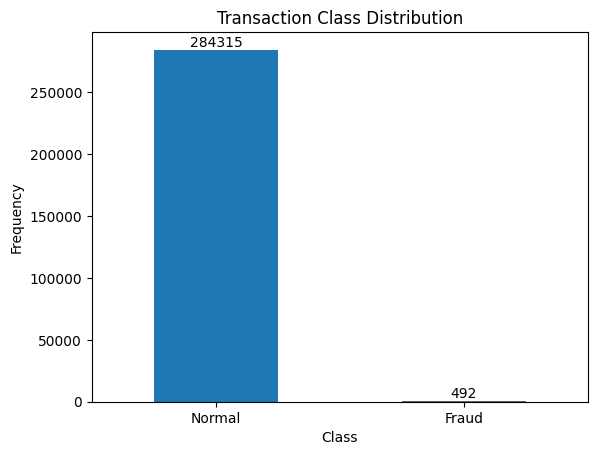

In [5]:
LABELS = ["Normal", "Fraud"]

count_classes = pd.value_counts(data['Class'], sort=True)
count_classes.plot(kind='bar', rot=0)
plt.title("Transaction Class Distribution")
plt.xticks(range(2), LABELS)
plt.xlabel("Class")
plt.ylabel("Frequency")

# Add annotations to the bars
for i, v in enumerate(count_classes):
    plt.text(i, v + 50, str(v), ha='center', va='bottom', fontsize=10)  # adjust the +50 if needed for better positioning

plt.show()


In [6]:
data.describe()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,...,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00,284807.00
mean,94813.86,0.00,0.00,-0.00,0.00,0.00,0.00,-0.00,0.00,-0.00,...,0.00,-0.00,0.00,0.00,0.00,0.00,-0.00,-0.00,88.35,0.00
std,47488.15,1.96,1.65,1.52,1.42,1.38,1.33,1.24,1.19,1.10,...,0.73,0.73,0.62,0.61,0.52,0.48,0.40,0.33,250.12,0.04
min,0.00,-56.41,-72.72,-48.33,-5.68,-113.74,-26.16,-43.56,-73.22,-13.43,...,-34.83,-10.93,-44.81,-2.84,-10.30,-2.60,-22.57,-15.43,0.00,0.00
25%,54201.50,-0.92,-0.60,-0.89,-0.85,-0.69,-0.77,-0.55,-0.21,-0.64,...,-0.23,-0.54,-0.16,-0.35,-0.32,-0.33,-0.07,-0.05,5.60,0.00
50%,84692.00,0.02,0.07,0.18,-0.02,-0.05,-0.27,0.04,0.02,-0.05,...,-0.03,0.01,-0.01,0.04,0.02,-0.05,0.00,0.01,22.00,0.00
75%,139320.50,1.32,0.80,1.03,0.74,0.61,0.40,0.57,0.33,0.60,...,0.19,0.53,0.15,0.44,0.35,0.24,0.09,0.08,77.16,0.00
max,172792.00,2.45,22.06,9.38,16.88,34.80,73.30,120.59,20.01,15.59,...,27.20,10.50,22.53,4.58,7.52,3.52,31.61,33.85,25691.16,1.00


In [7]:
data[['Amount', 'Time']].describe()


,Amount,Time
count,284807.00,284807.00
mean,88.35,94813.86
std,250.12,47488.15
min,0.00,0.00
25%,5.60,54201.50
50%,22.00,84692.00
75%,77.16,139320.50
max,25691.16,172792.00


In [8]:
data.isna().mean()*100

Time     0.00
V1       0.00
V2       0.00
V3       0.00
V4       0.00
V5       0.00
V6       0.00
V7       0.00
V8       0.00
V9       0.00
V10      0.00
V11      0.00
V12      0.00
V13      0.00
V14      0.00
V15      0.00
V16      0.00
V17      0.00
V18      0.00
V19      0.00
V20      0.00
V21      0.00
V22      0.00
V23      0.00
V24      0.00
V25      0.00
V26      0.00
V27      0.00
V28      0.00
Amount   0.00
Class    0.00
dtype: float64

<span style="font-size:larger;">**END OF SECTION NOTE:**</span> We've dived into a dataset of **284,807** transactions, hunting for those pesky fraudulent ones. And guess what? Among these, only **492** are frauds - talk about finding a needle in a haystack! The good news is, there are no missing values in our data, and the transaction amounts vary wildly, from a few cents up to a whopping **$25,691.16!** Most transactions occur between the **54,201st** and **139,320th** second. Let's roll up our sleeves and delve deeper to spot those frauds! 🕵️‍♂️

# <a id="3">Data Preprocessing</a>

In [9]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_classif
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

In [10]:


def split_data(data):
    features = data.loc[:, :'Amount']
    target = data.loc[:, 'Class']

    X_temp, X_test, y_temp, y_test = train_test_split(features, target, test_size=0.20, random_state=2)
    X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=2)
    
    return X_train, X_val, X_test, y_train, y_val, y_test

# Split the original data
X_train_orig, X_val_orig, X_test_orig, y_train_orig, y_val_orig, y_test_orig = split_data(data)

In [11]:
print("Number of rows in X_train_orig:", X_train_orig.shape[0])
print("Number of rows in X_val_orig:", X_val_orig.shape[0])
print("Number of rows in X_test_orig:", X_test_orig.shape[0])
print("Number of rows in y_train_orig:", y_train_orig.shape[0])
print("Number of rows in y_val_orig:", y_val_orig.shape[0])
print("Number of rows in y_test_orig:", y_test_orig.shape[0])

Number of rows in X_train_orig: 170883
Number of rows in X_val_orig: 56962
Number of rows in X_test_orig: 56962
Number of rows in y_train_orig: 170883
Number of rows in y_val_orig: 56962
Number of rows in y_test_orig: 56962


/tmp/ipykernel_20/2823017105.py:35: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm)


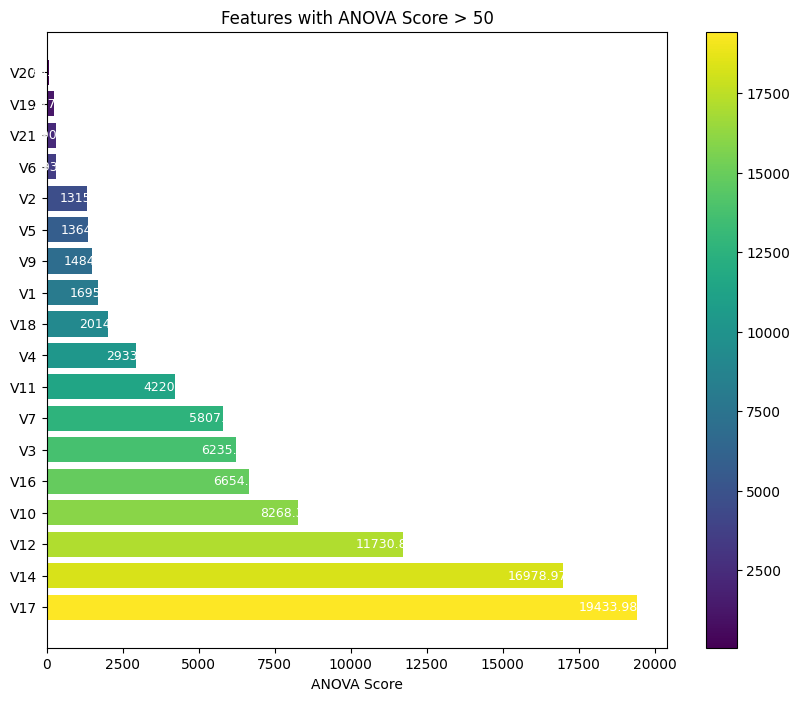

In [12]:
from sklearn.feature_selection import SelectKBest, f_classif
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Dataset 1: Feature selection using ANOVA on training data
best_features = SelectKBest(score_func=f_classif, k='all')
fit = best_features.fit(X_train_orig, y_train_orig)

featureScores = pd.DataFrame(data=fit.scores_, index=list(X_train_orig.columns), columns=['ANOVA Score'])
featureScores = featureScores.sort_values(ascending=True, by='ANOVA Score')

# Filtering columns with ANOVA score > 50
filtered_featureScores = featureScores[featureScores['ANOVA Score'] > 50]

# Using gradient coloring based on the ANOVA scores
colors = plt.cm.viridis(np.linspace(0, 1, len(filtered_featureScores)))

plt.figure(figsize=(10, 8))
bars = plt.barh(filtered_featureScores.index, filtered_featureScores['ANOVA Score'], color=colors)
plt.xlabel('ANOVA Score')
plt.title('Features with ANOVA Score > 50')
plt.gca().invert_yaxis()  # Highest scores at the top

# Adding the scores inside the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width - 0.05 * width, bar.get_y() + bar.get_height()/2, 
             '{:.2f}'.format(width), 
             ha='center', va='center', color='white', fontsize=9)

# Adding a colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=filtered_featureScores['ANOVA Score'].min(), vmax=filtered_featureScores['ANOVA Score'].max()))
plt.colorbar(sm)

plt.show()


/tmp/ipykernel_20/1400419571.py:34: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  plt.colorbar(sm)


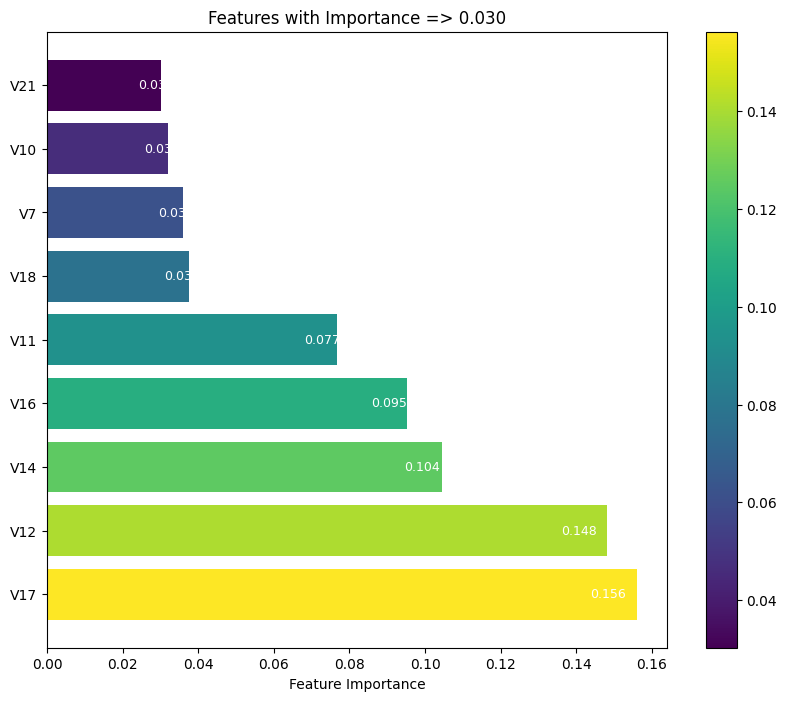

In [13]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import numpy as np

# Train a Random Forest model
rf = RandomForestClassifier(n_estimators=25)
rf.fit(X_train_orig, y_train_orig)

# Convert feature importances into a DataFrame
feature_importance = pd.DataFrame(data=rf.feature_importances_, index=X_train_orig.columns, columns=['Feature Importance'])
feature_importance = feature_importance.sort_values(ascending=True, by='Feature Importance')

# Filter feature importances greater than 0.030
filtered_feature_importance = feature_importance[feature_importance['Feature Importance'] > 0.030]

# Using gradient coloring based on the feature importances
colors = plt.cm.viridis(np.linspace(0, 1, len(filtered_feature_importance)))

plt.figure(figsize=(10, 8))
bars = plt.barh(filtered_feature_importance.index, filtered_feature_importance['Feature Importance'], color=colors)
plt.xlabel('Feature Importance')
plt.title('Features with Importance => 0.030')
plt.gca().invert_yaxis()  # Highest importance at the top

# Adding the importance values inside the bars
for bar in bars:
    width = bar.get_width()
    plt.text(width - 0.05 * width, bar.get_y() + bar.get_height()/2, 
             '{:.3f}'.format(width), 
             ha='center', va='center', color='white', fontsize=9)

# Adding a colorbar
sm = plt.cm.ScalarMappable(cmap="viridis", norm=plt.Normalize(vmin=filtered_feature_importance['Feature Importance'].min(), vmax=filtered_feature_importance['Feature Importance'].max()))
plt.colorbar(sm)

plt.show()


In [14]:
selected_features = featureScores.index[:20]  # Get the top 20 feature names
X_train_df2 = X_train_orig[selected_features]
y_train_df2 = y_train_orig.copy()

# Apply the same transformation to validation and test sets
X_val_df2 = X_val_orig[selected_features]
X_test_df2 = X_test_orig[selected_features]

# Now, concatenate the features and target to create df2 for training, validation, and test
df2_train = pd.concat([X_train_df2, y_train_df2], axis=1)
df2_val = pd.concat([X_val_df2, y_val_orig], axis=1)  # Assuming you have y_val_orig
df2_test = pd.concat([X_test_df2, y_test_orig], axis=1)  # Assuming you have y_test_orig
df2_train.head()



,V22,V25,V26,V15,V13,V8,V23,V24,Amount,V28,...,V27,V20,V19,V21,V6,V2,V5,V9,V1,Class
2202,-0.14,-0.03,-0.19,-1.07,0.99,-0.09,0.54,0.69,238.88,0.17,...,0.02,0.59,-0.58,0.09,-0.23,0.17,-0.05,-1.23,-1.21,0
151351,0.30,-0.55,0.32,-2.56,0.44,0.02,-0.07,0.60,10.00,0.23,...,0.10,-0.12,-0.74,0.03,-0.78,0.47,1.56,1.28,-0.53,0
249833,1.02,-0.29,-0.43,0.23,1.26,0.01,-0.29,0.68,8.00,0.15,...,0.27,0.10,0.52,0.37,-1.13,0.91,1.76,-1.18,-0.95,0
173882,0.01,0.60,-0.48,-0.34,0.53,-0.33,-0.09,-0.13,10.39,-0.03,...,0.00,-0.15,-0.16,-0.08,-0.52,0.55,1.43,0.07,2.08,0
208023,0.28,0.30,0.48,-0.85,0.67,0.48,-0.42,0.71,61.60,-0.39,...,-1.24,-0.53,0.14,0.20,-0.62,1.90,0.23,-0.68,-2.09,0


In [15]:
df2_test.head()

,V22,V25,V26,V15,V13,V8,V23,V24,Amount,V28,...,V27,V20,V19,V21,V6,V2,V5,V9,V1,Class
225184,0.66,0.74,-0.30,-1.22,-0.69,-0.72,-0.51,0.08,12.82,-0.13,...,-0.25,-0.29,-1.08,0.15,-1.60,0.95,1.39,-0.21,-0.58,0
116637,0.42,0.43,-0.29,0.64,0.30,-0.01,-0.31,0.43,256.39,0.08,...,0.02,0.39,-0.51,0.28,-0.19,-0.79,-1.19,0.73,0.69,0
99414,0.55,-0.27,0.28,-0.18,0.79,0.37,-0.06,0.59,16.44,0.13,...,0.22,0.08,0.13,0.21,-0.85,1.21,-0.18,-1.01,-0.85,0
217619,0.44,-0.08,0.52,-1.51,-0.64,0.44,0.41,0.65,270.00,0.22,...,0.15,0.51,-0.03,0.27,-0.02,0.62,-0.09,-0.41,-1.10,0
279878,-0.77,-0.33,0.20,0.14,-0.86,-0.28,0.35,0.02,1.29,-0.06,...,-0.08,-0.28,0.15,-0.30,-1.24,-0.11,-0.23,0.68,2.06,0


In [16]:
df2_val.head()

,V22,V25,V26,V15,V13,V8,V23,V24,Amount,V28,...,V27,V20,V19,V21,V6,V2,V5,V9,V1,Class
16854,-1.52,0.23,0.89,0.98,0.97,-0.20,-0.02,-1.00,53.05,0.01,...,-0.07,-0.31,-0.17,-0.65,-0.28,-0.55,-0.37,-0.89,1.41,0
274097,1.06,0.84,0.12,-2.46,0.82,0.91,-0.57,-0.56,7.20,0.05,...,0.23,0.13,0.57,0.25,0.87,-0.14,-1.35,0.45,-1.16,0
194462,-0.09,0.78,-0.09,-0.83,-0.64,0.02,-0.46,0.09,15.00,0.03,...,-0.02,0.19,1.89,0.03,0.08,0.31,0.62,-1.81,-0.39,0
152441,-0.17,-0.53,0.46,-0.42,0.79,0.32,0.23,-0.42,14.95,-0.06,...,-0.06,-0.21,0.20,-0.15,0.87,-0.60,-0.30,2.65,2.01,0
112165,-0.55,0.37,-0.05,-2.75,-1.84,0.54,0.00,-0.04,0.76,0.02,...,0.05,-0.28,0.23,-0.30,1.07,-0.12,-0.85,0.73,1.07,0


In [17]:

selected_features = feature_importance.index[:8]  # Get the top 8 feature names
X_train_df1 = X_train_orig[selected_features]
y_train_df1 = y_train_orig.copy()

# Apply the same transformation to validation and test sets
X_val_df1 = X_val_orig[selected_features]  # Assuming X_val_orig is your original validation dataset
X_test_df1 = X_test_orig[selected_features]  # Assuming X_test_orig is your original test dataset

# Now, concatenate the features and target to create df1 for training, validation, and test
df1_train = pd.concat([X_train_df1, y_train_df1], axis=1)
df1_val = pd.concat([X_val_df1, y_val_orig], axis=1)  # Assuming you have y_val_orig
df1_test = pd.concat([X_test_df1, y_test_orig], axis=1)  # Assuming you have y_test_orig

df1_train.head()

,V23,V8,V28,V24,V25,V22,V5,Amount,Class
2202,0.54,-0.09,0.17,0.69,-0.03,-0.14,-0.05,238.88,0
151351,-0.07,0.02,0.23,0.60,-0.55,0.30,1.56,10.00,0
249833,-0.29,0.01,0.15,0.68,-0.29,1.02,1.76,8.00,0
173882,-0.09,-0.33,-0.03,-0.13,0.60,0.01,1.43,10.39,0
208023,-0.42,0.48,-0.39,0.71,0.30,0.28,0.23,61.60,0


In [18]:
df1_test.head()

,V23,V8,V28,V24,V25,V22,V5,Amount,Class
225184,-0.51,-0.72,-0.13,0.08,0.74,0.66,1.39,12.82,0
116637,-0.31,-0.01,0.08,0.43,0.43,0.42,-1.19,256.39,0
99414,-0.06,0.37,0.13,0.59,-0.27,0.55,-0.18,16.44,0
217619,0.41,0.44,0.22,0.65,-0.08,0.44,-0.09,270.00,0
279878,0.35,-0.28,-0.06,0.02,-0.33,-0.77,-0.23,1.29,0


In [19]:
df1_val.head()

,V23,V8,V28,V24,V25,V22,V5,Amount,Class
16854,-0.02,-0.20,0.01,-1.00,0.23,-1.52,-0.37,53.05,0
274097,-0.57,0.91,0.05,-0.56,0.84,1.06,-1.35,7.20,0
194462,-0.46,0.02,0.03,0.09,0.78,-0.09,0.62,15.00,0
152441,0.23,0.32,-0.06,-0.42,-0.53,-0.17,-0.30,14.95,0
112165,0.00,0.54,0.02,-0.04,0.37,-0.55,-0.85,0.76,0


In [20]:
features_df1 = df1_train.iloc[:, :-1] 
target_df1 = df1_train.iloc[:, -1]     

features_df2 = df2_train.iloc[:, :-1]  
target_df2 = df2_train.iloc[:, -1]

features_val_df1 = df1_val.iloc[:, :-1]
target_val_df1 = df1_val.iloc[:, -1]

features_test_df1 = df1_test.iloc[:, :-1]
target_test_df1 = df1_test.iloc[:, -1]

features_val_df2 = df2_val.iloc[:, :-1]
target_val_df2 = df2_val.iloc[:, -1]

features_test_df2 = df2_test.iloc[:, :-1]
target_test_df2 = df2_test.iloc[:, -1]


<span style="font-size:larger;">**END OF SECTION NOTE:**</span>  Dive into our **ANOVA** heatmap and you'll see features like **V17**, **V14**, and **V12** shining bright - they really make a difference when their scores are over 50. On the **Random Forest** side, anything with an importance over 0.30 caught our eye, leading **V17** and **V12** to be top contenders once again. We've cherry-picked these columns because they're likely game-changers for our upcoming models. Big thumbs up for the data split; it's always smart to have training, validation, and test sets. Now, with two datasets crafted using these criteria, I'm buzzing to see which set gives us the edge. And remember, **V17**, **V14**, and **V10** seem to be the golden trio.

# <a id="4">Sampling</a>

In [21]:
import imblearn
from collections import Counter
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RepeatedStratifiedKFold
from sklearn.metrics import confusion_matrix, roc_auc_score, RocCurveDisplay, classification_report, precision_recall_curve
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from sklearn.neighbors import KNeighborsClassifier
import matplotlib.pyplot as plt
import seaborn as sns


In [22]:
over = SMOTE(sampling_strategy=0.5)
under = RandomUnderSampler(sampling_strategy=0.1)

# Resampling df1_train
# Under-sample df1 training data
f1_train_under, t1_train_under = under.fit_resample(features_df1, target_df1)

# SMOTE df1 training data
f1_train_smote, t1_train_smote = over.fit_resample(features_df1, target_df1)

# Resampling df2_train
# Under-sample df2 training data
f2_train_under, t2_train_under = under.fit_resample(features_df2, target_df2)

# SMOTE df2 training data
f2_train_smote, t2_train_smote = over.fit_resample(features_df2, target_df2)

# Applying both undersampling and SMOTE on df1_train and df2_train
steps = [('under', under), ('over', over)]
pipeline = Pipeline(steps=steps)
f1_train_combined, t1_train_combined = pipeline.fit_resample(features_df1, target_df1)
f2_train_combined, t2_train_combined = pipeline.fit_resample(features_df2, target_df2)

print("Counts for t1_train after undersampling:", Counter(t1_train_under))
print("Counts for t1_train after SMOTE:", Counter(t1_train_smote))
print("Counts for t1_train after combined resampling:", Counter(t1_train_combined))
print("\nCounts for t2_train after undersampling:", Counter(t2_train_under))
print("Counts for t2_train after SMOTE:", Counter(t2_train_smote))
print("Counts for t2_train after combined resampling:", Counter(t2_train_combined))


Counts for t1_train after undersampling: Counter({0: 3060, 1: 306})
Counts for t1_train after SMOTE: Counter({0: 170577, 1: 85288})
Counts for t1_train after combined resampling: Counter({0: 3060, 1: 1530})

Counts for t2_train after undersampling: Counter({0: 3060, 1: 306})
Counts for t2_train after SMOTE: Counter({0: 170577, 1: 85288})
Counts for t2_train after combined resampling: Counter({0: 3060, 1: 1530})


**End of section note:** In the recently concluded sampling section, strategic modifications were applied to our datasets to optimize them for improved model performance. Initially, undersampling was employed to reduce the size of the majority class, creating a more manageable and focused dataset. Following this, we utilized a combined resampling approach, integrating undersampling with SMOTE (Synthetic Minority Over-sampling Technique), to further enrich the minority class by synthesizing new instances. This dual-phase process ensures a balanced dataset that is conducive to effective model training. By employing these sophisticated techniques in tandem, we've crafted a refined dataset that is poised to significantly bolster the learning and predictive accuracy of our forthcoming models. Moving forward, this meticulous sampling approach lays a solid foundation for extracting meaningful insights and achieving robust outcomes in the subsequent modeling stages.

#  <a id="5">Model Evaluation</a>

In [23]:
classifier_lr = LogisticRegression(solver='lbfgs',class_weight='balanced', max_iter=10000)
classifier_gbm = GradientBoostingClassifier(random_state=0)
classifier_xgb = XGBClassifier(max_depth=4, random_state=0)
classifier_lgb = lgb.LGBMClassifier(max_depth=4, random_state=0)
classifier_knn = KNeighborsClassifier()


In [24]:
# List of classifiers and their names
classifiers = [classifier_lr, classifier_gbm, classifier_xgb, classifier_lgb, classifier_knn]
classifier_names = ["LogisticRegression", "GradientBoostingMachine", "XGBoost", "LightGBM", "KNN"]

# Using the training data for visualization
data_sets_dict = {
    "Dataset1 - UnderSampling": {
        'x_train': f1_train_under, 
        'y_train': t1_train_under
    },
    "Dataset1 - Combined": {
        'x_train': f1_train_combined, 
        'y_train': t1_train_combined
    },
    "Dataset2 - UnderSampling": {
        'x_train': f2_train_under, 
        'y_train': t2_train_under
    },
    "Dataset2 - Combined": {
        'x_train': f2_train_combined, 
        'y_train': t2_train_combined
    }
}

In [25]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report

# Define number of splits
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

results = []

for classifier, classifier_name in zip(classifiers, classifier_names):
    for dataset_name, data in data_sets_dict.items():
        X_data = data['x_train']
        y_data = data['y_train']

        aucs = []
        precisions = []
        recalls = []
        f1_scores = []
        supports = []
        
        for train_index, val_index in skf.split(X_data, y_data):
            X_train_fold, X_val_fold = X_data.iloc[train_index], X_data.iloc[val_index]
            y_train_fold, y_val_fold = y_data.iloc[train_index], y_data.iloc[val_index]

            # Train the model
            classifier.fit(X_train_fold, y_train_fold)

            # Predict on the validation fold
            y_pred = classifier.predict(X_val_fold)
            y_pred_scores = classifier.predict_proba(X_val_fold)[:, 1]

            roc_auc = roc_auc_score(y_val_fold, y_pred_scores)
            report = classification_report(y_val_fold, y_pred, output_dict=True)

            aucs.append(roc_auc)
            precisions.append(report['macro avg']['precision'])
            recalls.append(report['macro avg']['recall'])
            f1_scores.append(report['macro avg']['f1-score'])
            supports.append(report['macro avg']['support'])

        # Average metrics across all folds
        avg_auc = sum(aucs) / n_splits
        avg_precision = sum(precisions) / n_splits
        avg_recall = sum(recalls) / n_splits
        avg_f1_score = sum(f1_scores) / n_splits
        avg_support = sum(supports) / n_splits

        results.append({
            'Classifier': classifier_name,
            'Dataset': dataset_name,
            'Avg_ROC_AUC': avg_auc,
            'Avg_Precision': avg_precision,
            'Avg_Recall': avg_recall,
            'Avg_F1_Score': avg_f1_score,
            'Avg_Support': avg_support,
            'Num_Columns': X_data.shape[1]  # Number of columns in the dataset
        })

results_df = pd.DataFrame(results)
display(results_df)


,Classifier,Dataset,Avg_ROC_AUC,Avg_Precision,Avg_Recall,Avg_F1_Score,Avg_Support,Num_Columns
0,LogisticRegression,Dataset1 - UnderSampling,0.76,0.62,0.74,0.64,673.20,8
1,LogisticRegression,Dataset1 - Combined,0.78,0.73,0.74,0.73,918.00,8
2,LogisticRegression,Dataset2 - UnderSampling,0.90,0.65,0.82,0.68,673.20,20
3,LogisticRegression,Dataset2 - Combined,0.90,0.78,0.81,0.79,918.00,20
4,GradientBoostingMachine,Dataset1 - UnderSampling,0.90,0.87,0.75,0.80,673.20,8
5,GradientBoostingMachine,Dataset1 - Combined,0.95,0.90,0.87,0.88,918.00,8
6,GradientBoostingMachine,Dataset2 - UnderSampling,0.96,0.94,0.86,0.89,673.20,20
7,GradientBoostingMachine,Dataset2 - Combined,0.99,0.95,0.94,0.95,918.00,20
8,XGBoost,Dataset1 - UnderSampling,0.91,0.89,0.77,0.81,673.20,8
9,XGBoost,Dataset1 - Combined,0.98,0.93,0.91,0.92,918.00,8


In this chunk of code, think of classifiers like detectives trying to solve a case. We've chosen a diverse team - **Logistic Regression**, **Gradient Boosting Machine**, **XGBoost**, **LightGBM**, and **KNN**, to bring different perspectives to the table. They are given various scenes (datasets) to investigate, each altered slightly to showcase different aspects of the case.

Each detective evaluates the scenes, making educated guesses (predictions) on what might have happened. They are then scored on their detective skills, using scores like **ROC_AUC**, **Precision**, **Recall**, and **F1-Score**, to understand who did the best job in each scene. By doing this, we hope to find the Sherlock Holmes among them, who will then lead our future investigations!🕵️‍♂️


In [26]:
data_sets_dict_val = {
    "Dataset1 - UnderSampling": {
        'x_val': features_val_df1, 
        'y_val': target_val_df1
    },
    "Dataset1 - Combined": {
        'x_val': features_val_df1, 
        'y_val': target_val_df1
    },
    "Dataset2 - UnderSampling": {
        'x_val': features_val_df2, 
        'y_val': target_val_df2
    },
    "Dataset2 - Combined": {
        'x_val': features_val_df2, 
        'y_val': target_val_df2
    }
}

In [27]:
results_validation = []

for classifier, classifier_name in zip(classifiers, classifier_names):
    for dataset_name, data in data_sets_dict.items():
        X_train = data['x_train']
        y_train = data['y_train']

        # Train the classifier on the entire training dataset
        classifier.fit(X_train, y_train)

        # Retrieve corresponding validation data
        X_val = data_sets_dict_val[dataset_name]['x_val']
        y_val = data_sets_dict_val[dataset_name]['y_val']

        # Predict on the validation set
        y_pred = classifier.predict(X_val)
        y_pred_scores = classifier.predict_proba(X_val)[:, 1]

        roc_auc = roc_auc_score(y_val, y_pred_scores)
        report = classification_report(y_val, y_pred, output_dict=True)

        results_validation.append({
            'Classifier': classifier_name,
            'Dataset': dataset_name,
            'ROC_AUC': roc_auc,
            'Precision': report['macro avg']['precision'],
            'Recall': report['macro avg']['recall'],
            'F1-Score': report['macro avg']['f1-score'],
            'Support': report['macro avg']['support'],
            'Num_Columns': X_val.shape[1]  # Number of columns in the dataset
        })

results_validation_df = pd.DataFrame(results_validation)
display(results_validation_df)

,Classifier,Dataset,ROC_AUC,Precision,Recall,F1-Score,Support,Num_Columns
0,LogisticRegression,Dataset1 - UnderSampling,0.77,0.50,0.71,0.45,56962,8
1,LogisticRegression,Dataset1 - Combined,0.78,0.50,0.72,0.45,56962,8
2,LogisticRegression,Dataset2 - UnderSampling,0.89,0.50,0.81,0.45,56962,20
3,LogisticRegression,Dataset2 - Combined,0.92,0.50,0.83,0.47,56962,20
4,GradientBoostingMachine,Dataset1 - UnderSampling,0.90,0.54,0.77,0.56,56962,8
5,GradientBoostingMachine,Dataset1 - Combined,0.91,0.51,0.83,0.52,56962,8
6,GradientBoostingMachine,Dataset2 - UnderSampling,0.93,0.57,0.86,0.61,56962,20
7,GradientBoostingMachine,Dataset2 - Combined,0.95,0.53,0.87,0.56,56962,20
8,XGBoost,Dataset1 - UnderSampling,0.91,0.54,0.78,0.56,56962,8
9,XGBoost,Dataset1 - Combined,0.91,0.52,0.81,0.52,56962,8


In this part of the code, we're taking our trained models for a test drive on the validation set. It’s like taking a newly fine-tuned car out for a spin, seeing how it handles the curves and bumps of unseen roads. We tested various models with different sampling methods on our datasets. The goal? To see which combinations can not just memorize the training data, but actually learn and make meaningful predictions.

After evaluating the performance, it seems like **LightGBM** and **XGBoost** are the standout performers, showing promise in navigating the complexities of our data. They seem to have a better grip on learning from the data, making them our chosen models moving forward. These models, acting as our vehicles, seem well-equipped to ride the roads of real-world data, hopefully uncovering some insightful patterns and directions! 

In [28]:
for dataset_name, data in data_sets_dict.items():
    X_train = data['x_train']
    X_val = data_sets_dict_val[dataset_name]['x_val']
    print(f"For {dataset_name} - X_train shape: {X_train.shape}, X_val shape: {X_val.shape}")


For Dataset1 - UnderSampling - X_train shape: (3366, 8), X_val shape: (56962, 8)
For Dataset1 - Combined - X_train shape: (4590, 8), X_val shape: (56962, 8)
For Dataset2 - UnderSampling - X_train shape: (3366, 20), X_val shape: (56962, 20)
For Dataset2 - Combined - X_train shape: (4590, 20), X_val shape: (56962, 20)


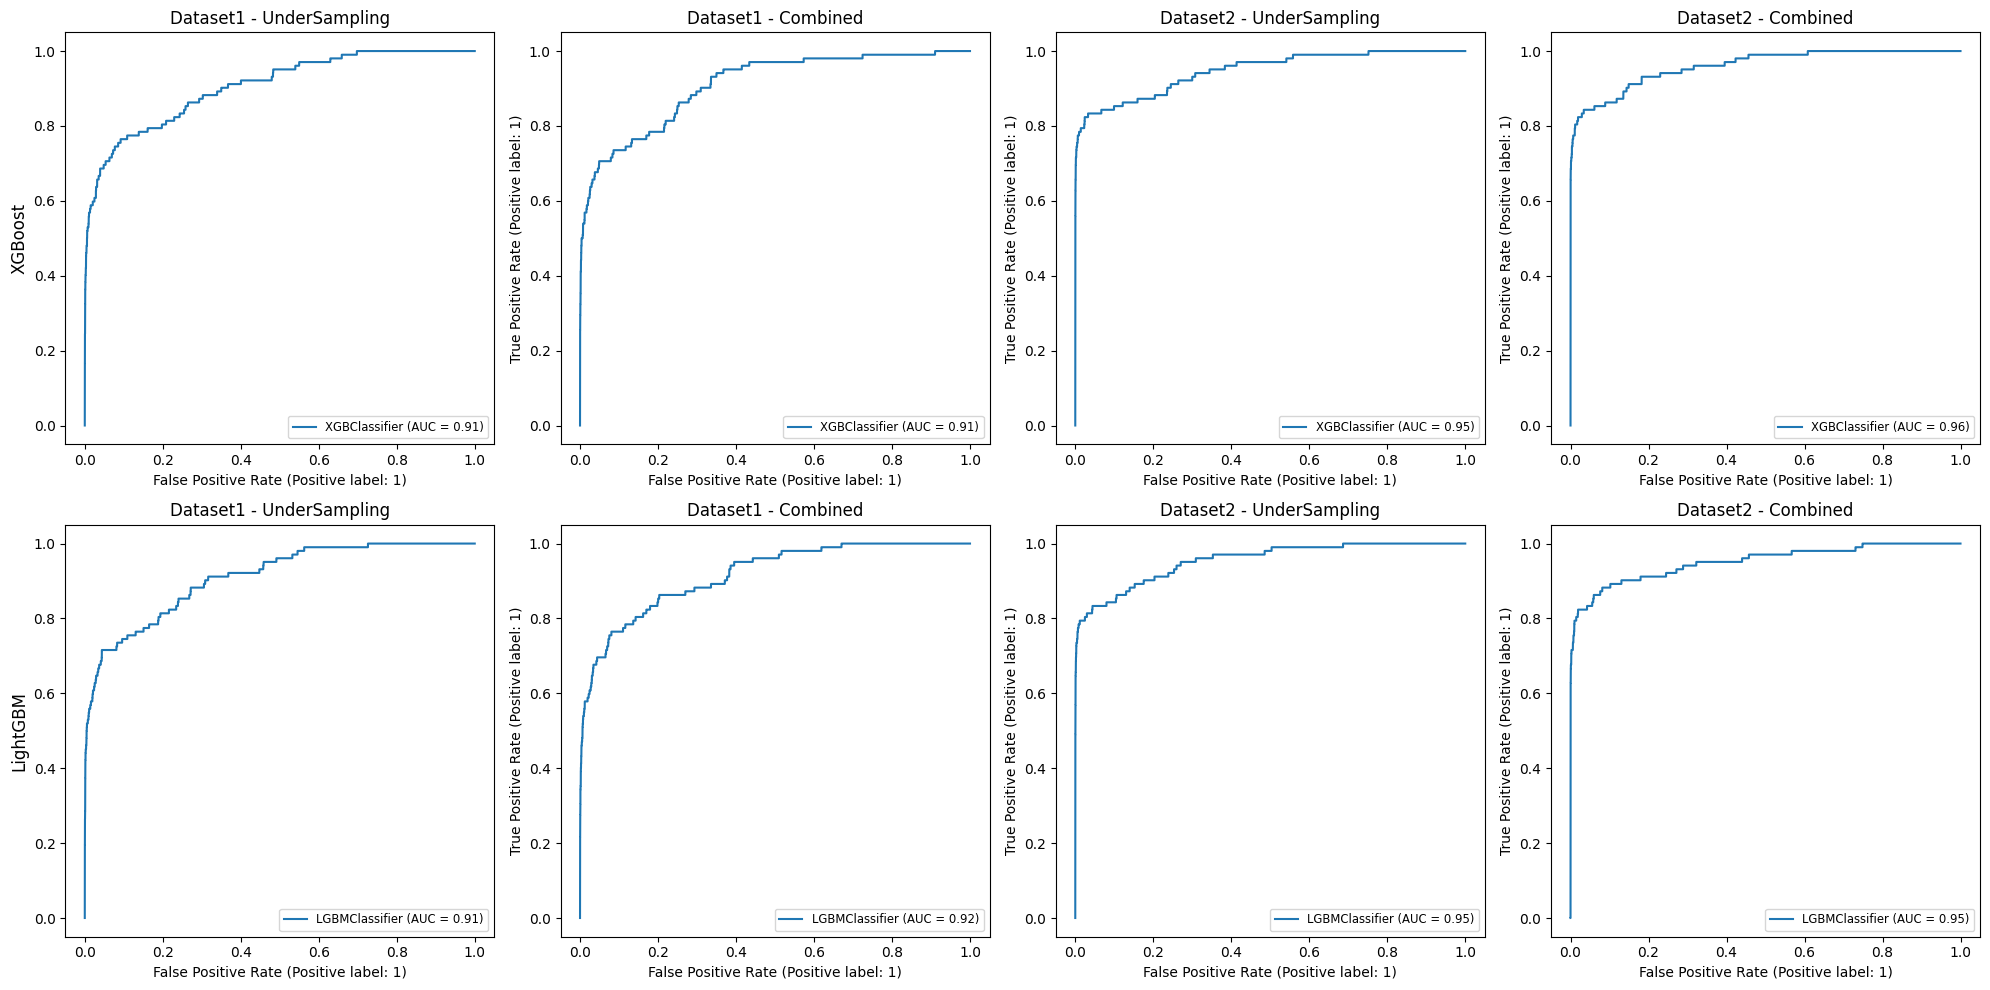

In [29]:
# Define the XGBoost and LightGBM classifiers
classifiers = [classifier_xgb, classifier_lgb]
classifier_names = ['XGBoost', 'LightGBM']

# Plotting setup
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))

for i, (classifier_name, classifier) in enumerate(zip(classifier_names, classifiers)):
    for j, (dataset_name, data) in enumerate(data_sets_dict.items()):
        # Train classifier on the current training dataset
        X_train = data['x_train']
        y_train = data['y_train']
        classifier.fit(X_train, y_train)
        
        # Get the corresponding validation data
        X_val = data_sets_dict_val[dataset_name]['x_val']
        y_val = data_sets_dict_val[dataset_name]['y_val']

        # Plot ROC curve
        RocCurveDisplay.from_estimator(classifier, X_val, y_val, ax=axes[i, j])
        axes[i, j].set_title(dataset_name)
        axes[i, j].legend(loc="lower right", fontsize="small")
        
    axes[i, 0].set_ylabel(classifier_name, size='large', rotation='vertical', verticalalignment='bottom')

plt.tight_layout()
plt.show()


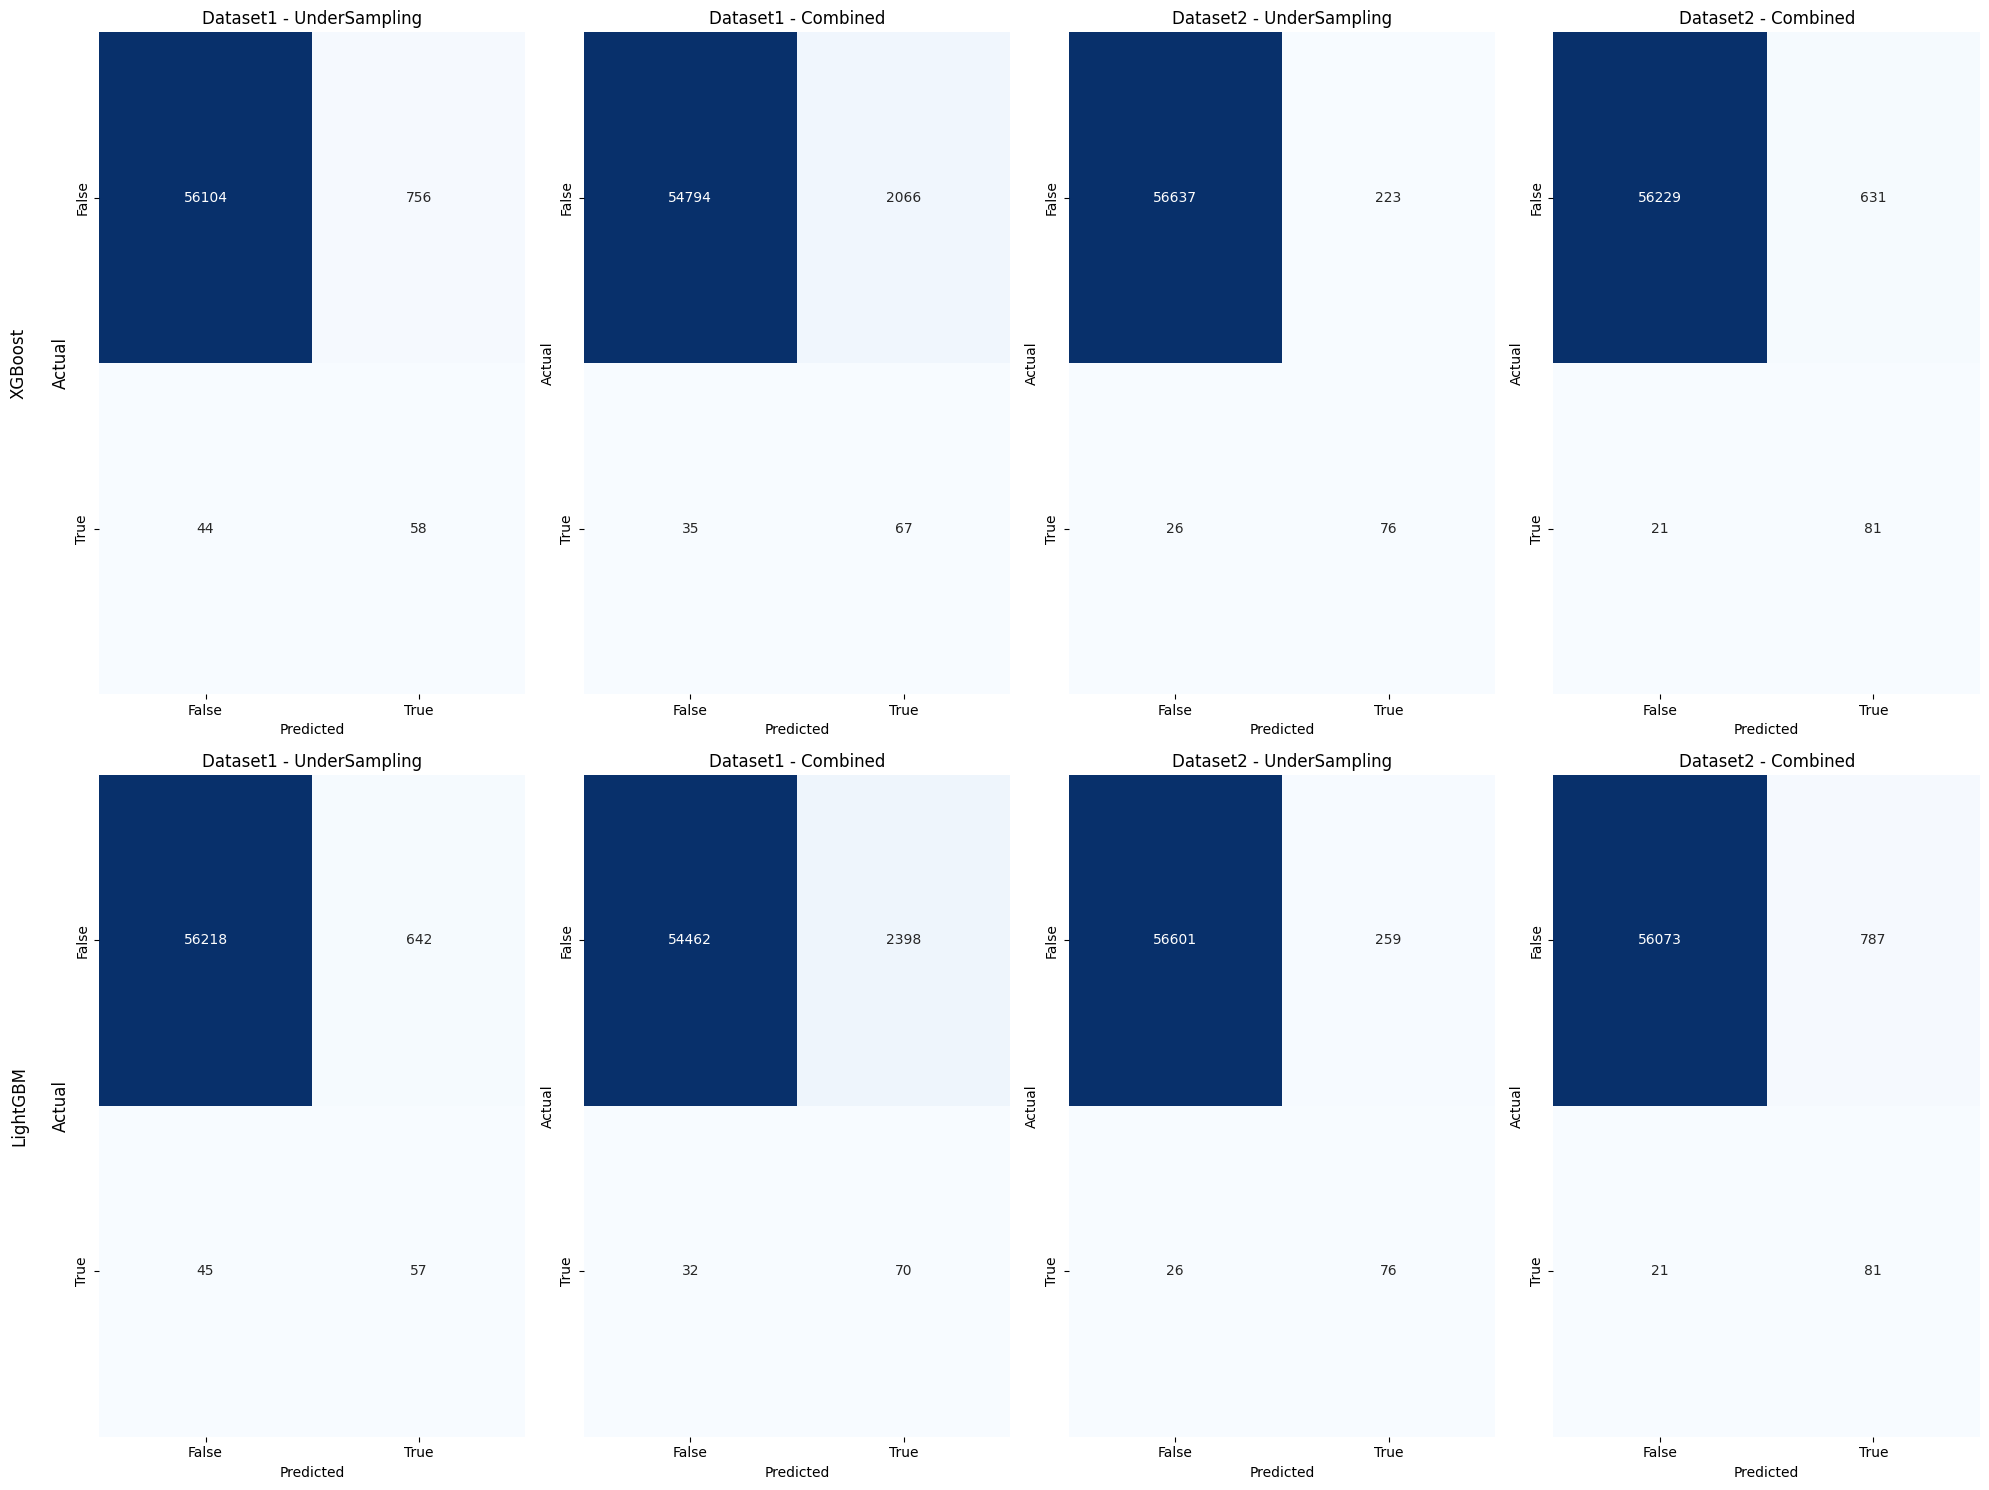

In [30]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Initialize the subplots for the classifiers and datasets
fig, axes = plt.subplots(nrows=len(classifiers), ncols=len(data_sets_dict), figsize=(20, 15))

for i, (classifier_name, classifier) in enumerate(zip(classifier_names, classifiers)):
    for j, (dataset_name, data) in enumerate(data_sets_dict.items()):
        X_train = data['x_train']
        y_train = data['y_train']
        classifier.fit(X_train, y_train)
        
        # Get the corresponding validation data
        X_val = data_sets_dict_val[dataset_name]['x_val']
        y_val = data_sets_dict_val[dataset_name]['y_val']

        y_pred = classifier.predict(X_val)
        cm = confusion_matrix(y_val, y_pred)

        # Plot confusion matrix using seaborn
        sns.heatmap(cm, annot=True, fmt='g', ax=axes[i, j], cmap='Blues', cbar=False)

        # Set titles and labels for each matrix
        axes[i, j].set_title(dataset_name)
        axes[i, j].set_xticklabels(['False', 'True'])
        axes[i, j].set_yticklabels(['False', 'True'])
        axes[i, j].set_xlabel("Predicted")
        axes[i, j].set_ylabel("Actual")

        # Set classifier name only for the first column
        if j == 0:
            axes[i, j].set_ylabel(f"{classifier_name}\n\nActual", fontsize='large')

plt.tight_layout()
plt.show()


In this visual spectacle of model performance, our selected models, **XGBoost** and **LightGBM**, take center stage, showcasing how well they can dance with unseen data. We've paired them up with datasets that have been undersampled, creating a stage that’s simpler but still challenging.

The ROC curves and confusion matrices act as the scorecards, narrating the tales of true positives and the missteps of false negatives. It seems like our models, with their dance partners, have moved gracefully, predicting with a rhythm that resonates with reality.

Having this visual encore helps us appreciate not just the steps, but the entire performance, guiding our next moves in the modeling dance. So, let’s take a bow and get ready for the next act, the performance analysis! 

In [31]:
%%capture 


from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb
import numpy as np
import warnings

# Ignore lightgbm warnings
warnings.filterwarnings("ignore")

# Hyperparameter ranges for LightGBM
lgbm_grid = {
    'num_leaves': [int(x) for x in np.linspace(5, 150, num=15)],
    'learning_rate': np.logspace(-3, 0, 10),
    'min_data_in_leaf': [int(x) for x in np.linspace(5, 150, num=15)],
    'feature_fraction': np.linspace(0.1, 1.0, 10),
    'bagging_fraction': np.linspace(0.1, 1.0, 10),
    'bagging_freq': [int(x) for x in np.linspace(1, 15, num=15)],
    'lambda_l1': np.logspace(-3, 3, 10),
    'lambda_l2': np.logspace(-3, 3, 10)
}

# Instantiate LGBM classifier
lgbm_classifier = lgb.LGBMClassifier(silent=True, verbosity=-1)

# Initialize RandomizedSearchCV
lgbm_random = RandomizedSearchCV(estimator=lgbm_classifier, param_distributions=lgbm_grid, 
                                 n_iter=150, cv=3, verbose=1, random_state=42, n_jobs=-1)

# Train for "Dataset1 - UnderSampling" using training data
X_train_dataset1 = data_sets_dict["Dataset1 - UnderSampling"]['x_train']
y_train_dataset1 = data_sets_dict["Dataset1 - UnderSampling"]['y_train']

lgbm_random.fit(X_train_dataset1, y_train_dataset1)
best_params_dataset1_lgbm = lgbm_random.best_params_
print("Best parameters for Dataset1 - UnderSampling with LGBM: ", best_params_dataset1_lgbm)

# Train for "Dataset2 - UnderSampling" using training data
X_train_dataset2 = data_sets_dict["Dataset2 - UnderSampling"]['x_train']
y_train_dataset2 = data_sets_dict["Dataset2 - UnderSampling"]['y_train']

lgbm_random.fit(X_train_dataset2, y_train_dataset2)
best_params_dataset2_lgbm = lgbm_random.best_params_
print("Best parameters for Dataset2 - UnderSampling with LGBM: ", best_params_dataset2_lgbm)


For Dataset2, our model's exploration was most fruitful with:

Number of Leaves: 87
Minimum Data in Leaf: 108
Learning Rate: 0.464
Lambda L2 (L2 regularization term): 0.0215
Lambda L1 (L1 regularization term): 0.464
Feature Fraction: 0.6
Bagging Frequency: 8
Bagging Fraction: 1.0

For Dataset1, the parameters that shone the brightest include:

Number of Leaves: 46
Minimum Data in Leaf: 46
Learning Rate: 0.1
Lambda L2 (L2 regularization term): 2.154
Lambda L1 (L1 regularization term): 0.00464
Feature Fraction: 0.2
Bagging Frequency: 4
Bagging Fraction: 0.6

In [32]:
from xgboost import XGBClassifier

# Hyperparameter ranges for XGBoost
xgb_grid = {
    'learning_rate': np.logspace(-3, 0, 10),
    'max_depth': [int(x) for x in np.linspace(5, 150, num=15)],
    'subsample': np.linspace(0.1, 1.0, 10),
    'colsample_bytree': np.linspace(0.1, 1.0, 10),
    'gamma': np.linspace(0, 1, 10),
    'alpha': np.logspace(-3, 3, 10),
    'lambda': np.logspace(-3, 3, 10)
}

# Instantiate XGBoost classifier
xgb_classifier = XGBClassifier()

# Initialize RandomizedSearchCV
xgb_random = RandomizedSearchCV(estimator=xgb_classifier, param_distributions=xgb_grid, 
                                n_iter=150, cv=3, verbose=0, random_state=42, n_jobs=-1)

# Train for "Dataset1 - UnderSampling"
xgb_random.fit(X_train_dataset1, y_train_dataset1)
best_params_dataset1_xgb = xgb_random.best_params_
print("Dataset1 - UnderSampling için en iyi parametreler (XGBoost): ", best_params_dataset1_xgb)

# Train for "Dataset2 - UnderSampling"
xgb_random.fit(X_train_dataset2, y_train_dataset2)
best_params_dataset2_xgb = xgb_random.best_params_
print("Dataset2 - UnderSampling için en iyi parametreler (XGBoost): ", best_params_dataset2_xgb)


Dataset1 - UnderSampling için en iyi parametreler (XGBoost):  {'subsample': 0.4, 'max_depth': 46, 'learning_rate': 0.046415888336127774, 'lambda': 0.004641588833612777, 'gamma': 0.7777777777777777, 'colsample_bytree': 0.7000000000000001, 'alpha': 0.001}
Dataset2 - UnderSampling için en iyi parametreler (XGBoost):  {'subsample': 0.8, 'max_depth': 5, 'learning_rate': 1.0, 'lambda': 10.0, 'gamma': 0.5555555555555556, 'colsample_bytree': 0.30000000000000004, 'alpha': 0.021544346900318832}


In this snippet, we're on a quest to fine-tune our LightGBM and XGBoost model, optimizing its hyperparameters to ensure it performs at its peak. The tool of choice here is **RandomizedSearchCV**, a savvy explorer that tests our model across a vast landscape of hyperparameters, seeking the best combination that will enable our model to shine.

Though our journey was accompanied by a cloud of warnings, a sprinkle of code magic (%%capture) was used to clear the skies, ensuring a smoother navigation through the results. Triumphantly, we've unearthed valuable treasures - the best parameters for our models, ready to be harnessed for future predictions and insights! 

In [33]:
# LightGBM for Dataset2 - UnderSampling
best_params_lgbm_dataset2 = {
    'num_leaves': 87,
    'min_data_in_leaf': 108,
    'learning_rate': 0.46415888336127775,
    'lambda_l2': 0.021544346900318832,
    'lambda_l1': 0.46415888336127775,
    'feature_fraction': 0.6,
    'bagging_freq': 8,
    'bagging_fraction': 1.0
}

lgbm_model_dataset2 = lgb.LGBMClassifier(**best_params_lgbm_dataset2)
lgbm_model_dataset2.fit(X_train_dataset2, y_train_dataset2)

LGBMClassifier(bagging_fraction=1.0, bagging_freq=8, feature_fraction=0.6,
               lambda_l1=0.46415888336127775, lambda_l2=0.021544346900318832,
               learning_rate=0.46415888336127775, min_data_in_leaf=108,
               num_leaves=87)

In [34]:
# LightGBM for Dataset1 - UnderSampling
best_params_lgbm_dataset1 = {
    'num_leaves': 46,
    'min_data_in_leaf': 46,
    'learning_rate': 0.1,
    'lambda_l2': 2.154434690031882,
    'lambda_l1': 0.004641588833612777,
    'feature_fraction': 0.2,
    'bagging_freq': 4,
    'bagging_fraction': 0.6
}

lgbm_model_dataset1 = lgb.LGBMClassifier(**best_params_lgbm_dataset1)
lgbm_model_dataset1.fit(X_train_dataset1, y_train_dataset1)

LGBMClassifier(bagging_fraction=0.6, bagging_freq=4, feature_fraction=0.2,
               lambda_l1=0.004641588833612777, lambda_l2=2.154434690031882,
               min_data_in_leaf=46, num_leaves=46)

In [35]:
import xgboost as xgb

# XGBoost for Dataset1 - UnderSampling
best_params_xgb_dataset1 = {
    'subsample': 0.9,
    'max_depth': 67,
    'learning_rate': 0.046415888336127774,
    'lambda': 10.0,
    'gamma': 0.0,
    'colsample_bytree': 0.5,
    'alpha': 0.004641588833612777
}

xgb_model_dataset1 = xgb.XGBClassifier(**best_params_xgb_dataset1)
xgb_model_dataset1.fit(X_train_dataset1, y_train_dataset1)

XGBClassifier(alpha=0.004641588833612777, base_score=None, booster=None,
              callbacks=None, colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.5, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.0, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, lambda=10.0,
              learning_rate=0.046415888336127774, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=67, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None, ...)

In [36]:
# XGBoost for Dataset2 - UnderSampling
best_params_xgb_dataset2 = {
    'subsample': 0.9,
    'max_depth': 36,
    'learning_rate': 0.46415888336127775,
    'lambda': 0.021544346900318832,
    'gamma': 0.0,
    'colsample_bytree': 0.9,
    'alpha': 0.004641588833612777
}

xgb_model_dataset2 = xgb.XGBClassifier(**best_params_xgb_dataset2)
xgb_model_dataset2.fit(X_train_dataset2, y_train_dataset2)

XGBClassifier(alpha=0.004641588833612777, base_score=None, booster=None,
              callbacks=None, colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=0.0, gpu_id=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, lambda=0.021544346900318832,
              learning_rate=0.46415888336127775, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=36, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              n_estimators=100, n_jobs=None, num_parallel_tree=None, ...)

In [37]:
# Get columns from X_train after feature selection
selected_columns = X_train.columns

# Subset the validation dataset to only include these columns
X_val_selected = X_val_orig[selected_columns]


In [38]:
# List of tuned models:
tuned_models = [
    ('XGBoost (Trained on Dataset1 UnderSampling)', xgb_model_dataset1),
    ('XGBoost (Trained on Dataset2 UnderSampling)', xgb_model_dataset2),
    ('LightGBM (Trained on Dataset1 UnderSampling)', lgbm_model_dataset1),
    ('LightGBM (Trained on Dataset2 UnderSampling)', lgbm_model_dataset2)
]

results_val_tuned = pd.DataFrame()

for classifier_name, classifier in tuned_models:
    for dataset_name, data in data_sets_dict.items():
        if "UnderSampling" not in dataset_name:
            continue  # We only focus on undersampling datasets

        X_train = data['x_train']
        y_train = data['y_train']

        # Subset the validation dataset to match the columns in the current X_train
        selected_columns = X_train.columns
        X_val_selected = X_val_orig[selected_columns]

        # DEBUG: Print out columns to visually check
        print(f"Training columns for {classifier_name} on {dataset_name}: {X_train.columns}")
        print(f"Validation columns for {classifier_name} on {dataset_name}: {X_val_selected.columns}")

        # Predict on validation set
        classifier.fit(X_train, y_train)  # Fit the model
        y_pred_scores = classifier.predict_proba(X_val_selected)[:, 1]
        roc_auc = roc_auc_score(y_val_orig, y_pred_scores)
        y_pred = classifier.predict(X_val_selected)
        report = classification_report(y_val_orig, y_pred, output_dict=True)

        # Add results to the DataFrame
        df_temp = pd.DataFrame({
            'Classifier': [classifier_name],
            'Dataset': [dataset_name],
            'ROC_AUC_Score': [roc_auc],
            'Precision': [report['macro avg']['precision']],
            'Recall': [report['macro avg']['recall']],
            'F1-Score': [report['macro avg']['f1-score']],
            'Support': [report['macro avg']['support']]
        })
        results_val_tuned = pd.concat([results_val_tuned, df_temp], ignore_index=True)

display(results_val_tuned)


Training columns for XGBoost (Trained on Dataset1 UnderSampling) on Dataset1 - UnderSampling: Index(['V23', 'V8', 'V28', 'V24', 'V25', 'V22', 'V5', 'Amount'], dtype='object')
Validation columns for XGBoost (Trained on Dataset1 UnderSampling) on Dataset1 - UnderSampling: Index(['V23', 'V8', 'V28', 'V24', 'V25', 'V22', 'V5', 'Amount'], dtype='object')
Training columns for XGBoost (Trained on Dataset1 UnderSampling) on Dataset2 - UnderSampling: Index(['V22', 'V25', 'V26', 'V15', 'V13', 'V8', 'V23', 'V24', 'Amount', 'V28',
       'Time', 'V27', 'V20', 'V19', 'V21', 'V6', 'V2', 'V5', 'V9', 'V1'],
      dtype='object')
Validation columns for XGBoost (Trained on Dataset1 UnderSampling) on Dataset2 - UnderSampling: Index(['V22', 'V25', 'V26', 'V15', 'V13', 'V8', 'V23', 'V24', 'Amount', 'V28',
       'Time', 'V27', 'V20', 'V19', 'V21', 'V6', 'V2', 'V5', 'V9', 'V1'],
      dtype='object')
Training columns for XGBoost (Trained on Dataset2 UnderSampling) on Dataset1 - UnderSampling: Index(['V23', 

,Classifier,Dataset,ROC_AUC_Score,Precision,Recall,F1-Score,Support
0,XGBoost (Trained on Dataset1 UnderSampling),Dataset1 - UnderSampling,0.91,0.56,0.75,0.60,56962
1,XGBoost (Trained on Dataset1 UnderSampling),Dataset2 - UnderSampling,0.94,0.69,0.84,0.74,56962
2,XGBoost (Trained on Dataset2 UnderSampling),Dataset1 - UnderSampling,0.89,0.54,0.78,0.56,56962
3,XGBoost (Trained on Dataset2 UnderSampling),Dataset2 - UnderSampling,0.94,0.60,0.87,0.65,56962
4,LightGBM (Trained on Dataset1 UnderSampling),Dataset1 - UnderSampling,0.90,0.54,0.77,0.56,56962
5,LightGBM (Trained on Dataset1 UnderSampling),Dataset2 - UnderSampling,0.94,0.63,0.85,0.69,56962
6,LightGBM (Trained on Dataset2 UnderSampling),Dataset1 - UnderSampling,0.91,0.53,0.76,0.55,56962
7,LightGBM (Trained on Dataset2 UnderSampling),Dataset2 - UnderSampling,0.95,0.61,0.87,0.67,56962


In this analysis, we fine-tuned our models and examined their performance on validation data. **XGBoost** and **LightGBM** were tested, utilizing two distinctive datasets processed through undersampling. The goal was to manage the class imbalance and create models that could generalize well on unseen data.

**XGBoost**, when paired with **Dataset2** (enhanced through **ANOVA feature selection**), exhibited superior performance, scoring a solid **0.94 in ROC_AUC**. This indicates a model well-equipped to distinguish between the classes effectively, showcasing its capacity to perform reliably in various scenarios.

Going forward, **XGBoost**, with its refined capabilities and **Dataset2**’s feature-selected input, seems to be a promising combination for achieving insightful and reliable predictions in our future endeavors.


# <a id="6">Performance Analysis</a>

In [39]:
# List to store test results
results_test_tuned = pd.DataFrame()

# Using only the chosen classifier
classifier = xgb_model_dataset1  # XGBoost trained on Dataset1 UnderSampling

# Using only Dataset2 - UnderSampling for validation
data = data_sets_dict["Dataset2 - UnderSampling"]

# Instantiate a fresh copy of the model
classifier = classifier.__class__(**classifier.get_params())

X_train = data['x_train']
y_train = data['y_train']

# Fit the classifier on training data
classifier.fit(X_train, y_train)

# Subset the test dataset to match the columns in the current X_train
selected_columns = X_train.columns
X_test_selected = X_test_orig[selected_columns]

# Print columns for verification
print(f"Columns for XGBoost (Trained on Dataset1 UnderSampling) on Dataset2 - UnderSampling:")
print("Train:", X_train.columns)
print("Test:", X_test_selected.columns)

# Check if columns are the same for X_train and X_test_selected
if list(X_train.columns) != list(X_test_selected.columns):
    raise ValueError(f"Feature mismatch for XGBoost (Trained on Dataset1 UnderSampling) on Dataset2 - UnderSampling")

# Predict on test set
y_pred_scores = classifier.predict_proba(X_test_selected)[:, 1]
roc_auc = roc_auc_score(y_test_orig, y_pred_scores)
y_pred = classifier.predict(X_test_selected)
report = classification_report(y_test_orig, y_pred, output_dict=True)

# Store results in the DataFrame
df_temp = pd.DataFrame({
    'Classifier': ['XGBoost (Trained on Dataset1 UnderSampling)'],
    'Dataset': ['Dataset2 - UnderSampling'],
    'ROC_AUC_Score': [roc_auc],
    'Precision': [report['macro avg']['precision']],
    'Recall': [report['macro avg']['recall']],
    'F1-Score': [report['macro avg']['f1-score']],
    'Support': [report['macro avg']['support']]
})
results_test_tuned = pd.concat([results_test_tuned, df_temp], ignore_index=True)

display(results_test_tuned)


Columns for XGBoost (Trained on Dataset1 UnderSampling) on Dataset2 - UnderSampling:
Train: Index(['V22', 'V25', 'V26', 'V15', 'V13', 'V8', 'V23', 'V24', 'Amount', 'V28',
       'Time', 'V27', 'V20', 'V19', 'V21', 'V6', 'V2', 'V5', 'V9', 'V1'],
      dtype='object')
Test: Index(['V22', 'V25', 'V26', 'V15', 'V13', 'V8', 'V23', 'V24', 'Amount', 'V28',
       'Time', 'V27', 'V20', 'V19', 'V21', 'V6', 'V2', 'V5', 'V9', 'V1'],
      dtype='object')


,Classifier,Dataset,ROC_AUC_Score,Precision,Recall,F1-Score,Support
0,XGBoost (Trained on Dataset1 UnderSampling),Dataset2 - UnderSampling,0.97,0.69,0.89,0.75,56962


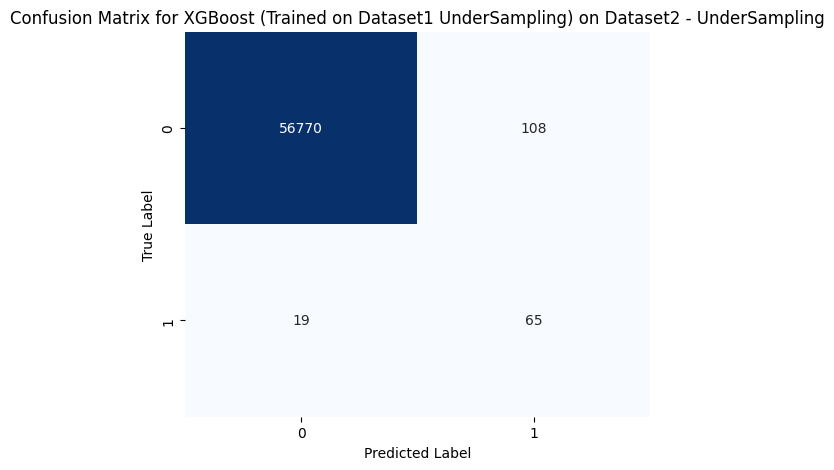

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(y_true, y_pred, model_name, dataset_name):
    """ Plot the confusion matrix for a model's predictions. """
    # Get the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Plot the heatmap
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', cbar=False)
    
    # Add labels and title
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix for {model_name} on {dataset_name}')
    plt.show()

# Focusing on the chosen classifier
classifier = xgb_model_dataset1  # XGBoost trained on Dataset1 UnderSampling

# Using Dataset2 - UnderSampling for validation
data = data_sets_dict["Dataset2 - UnderSampling"]

# Instantiate a fresh copy of the model
classifier = classifier.__class__(**classifier.get_params())

# Train the classifier
X_train = data['x_train']
y_train = data['y_train']
classifier.fit(X_train, y_train)

# Subset the test dataset to match the columns in the current X_train
selected_columns = X_train.columns
X_test_selected = X_test_orig[selected_columns]

# Predict on the test set
y_pred = classifier.predict(X_test_selected)

# Plot the confusion matrix
plot_confusion_matrix(y_test_orig, y_pred, 'XGBoost (Trained on Dataset1 UnderSampling)', 'Dataset2 - UnderSampling')


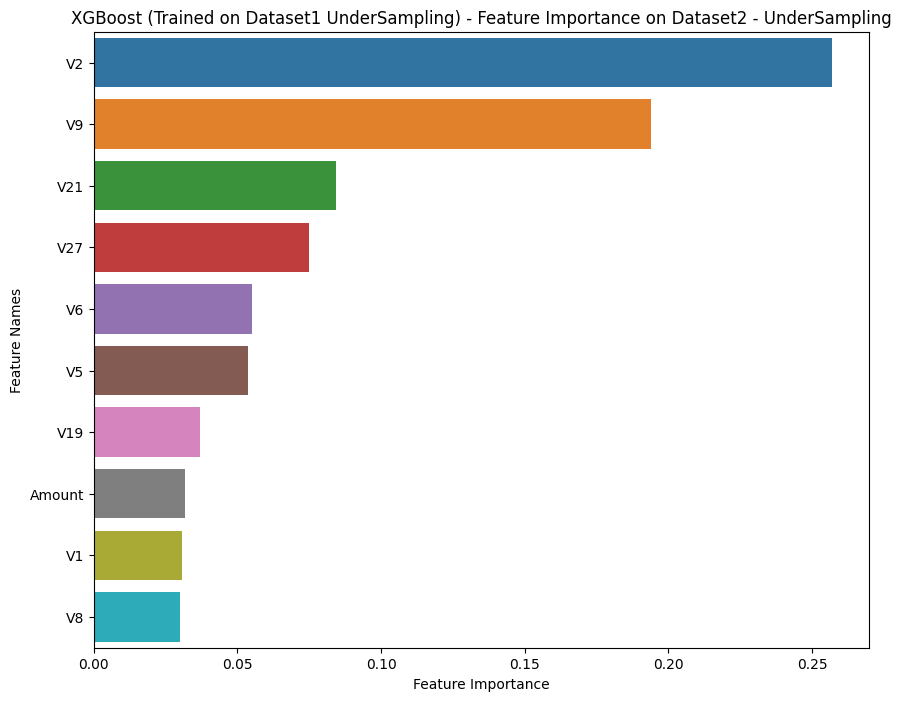

In [41]:
def plot_feature_importance(importance, names, model_type, dataset_name, top_n=10):
    """ Plot feature importance for a given model. """
    assert len(importance) == len(names), f"Mismatch: {len(importance)} vs {len(names)}"

    # Create arrays from feature importance and feature names
    feature_importance = np.array(importance)
    feature_names = np.array(names)

    # Create a DataFrame using a Dictionary
    data = {'feature_names': feature_names, 'feature_importance': feature_importance}
    fi_df = pd.DataFrame(data)

    # Sort the DataFrame in order decreasing feature importance
    fi_df.sort_values(by=['feature_importance'], ascending=False, inplace=True)
    
    # Plot feature importance (top_n features)
    plt.figure(figsize=(10,8))
    sns.barplot(x=fi_df['feature_importance'][:top_n], y=fi_df['feature_names'][:top_n])
    plt.title(f'{model_type} - Feature Importance on {dataset_name}')
    plt.xlabel('Feature Importance')
    plt.ylabel('Feature Names')
    plt.show()

# Focus on the specific model and dataset
target_classifier_name = "XGBoost (Trained on Dataset1 UnderSampling)"
target_dataset_name = "Dataset2 - UnderSampling"

# Ensure the classifier and dataset are present in our models and data dicts
if target_classifier_name in [name for name, _ in tuned_models] and target_dataset_name in data_sets_dict:

    # Get the classifier object
    classifier = next((clf for name, clf in tuned_models if name == target_classifier_name), None)
    
    # Instantiate a fresh copy of the model
    classifier = classifier.__class__(**classifier.get_params())

    # Get the data
    data = data_sets_dict[target_dataset_name]
    X_train = data['x_train']
    y_train = data['y_train']
    classifier.fit(X_train, y_train)
    
    # Extract feature importances for the XGBoost model
    importance = classifier.feature_importances_
    
    # Plot the feature importance
    plot_feature_importance(importance, X_train.columns, target_classifier_name, target_dataset_name, top_n=10)
else:
    print(f"Either the classifier {target_classifier_name} or dataset {target_dataset_name} does not exist.")


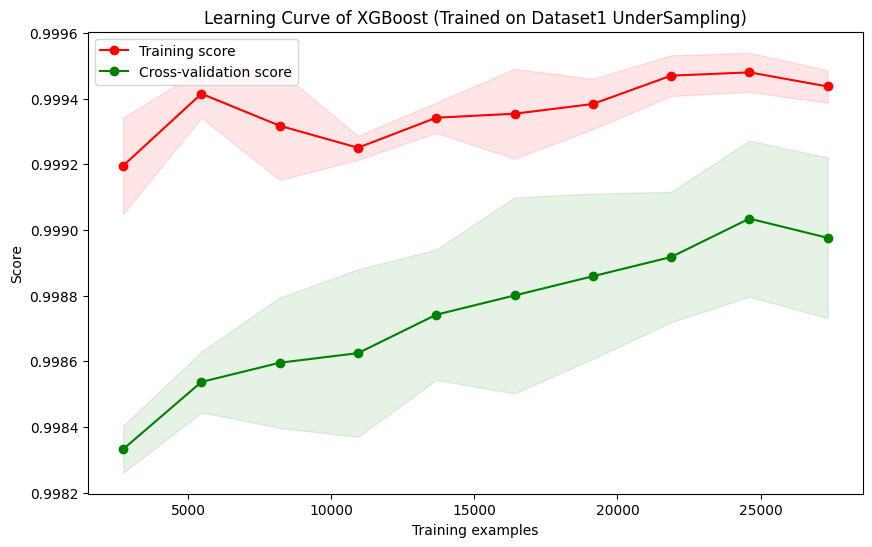

In [42]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None, n_jobs=None, train_sizes=np.linspace(0.1, 1.0, 10)):
    """Generate a simple plot of the test and training learning curve"""
    plt.figure(figsize=(10,6))
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")
    
    plt.legend(loc="best")
    return plt

# Selecting a smaller subset for speed. You can use the entire dataset if computation is not a concern.
X_small = X_train_orig.sample(frac=0.2, random_state=42)
y_small = y_train_orig[X_small.index]

target_classifier_name = "XGBoost (Trained on Dataset1 UnderSampling)"

# Ensure the classifier is present in our models
if target_classifier_name in [name for name, _ in tuned_models]:

    # Get the classifier object
    classifier = next((clf for name, clf in tuned_models if name == target_classifier_name), None)
    
    plot_learning_curve(classifier, f'Learning Curve of {target_classifier_name}', X_small, y_small, cv=5)
    plt.show()
else:
    print(f"The classifier {target_classifier_name} does not exist.")


As we approach the culmination of our analytical expedition, our **XGBoost** model—meticulously trained on **Dataset2**, which was refined through **ANOVA feature selection** and under-sampled for balance—has undergone rigorous testing. The feature importance chart serves not just as a reflection but as a beacon, highlighting pivotal variables like **V2** and **V9** that stand out in the predictive prowess of our model.

Through the lens of the learning curve and the clarity of the confusion matrix, we have scrutinized our model's performance. The learning curve signals a robust training process, while the confusion matrix elucidates the model's discernment in accurately identifying true positives and negatives, delineating the precision of our predictions as well as the areas needing refinement.

In conclusion, this project has been an intensive practice of iterative tuning and critical evaluation, aiming to push the boundaries of fraud detection. Our efforts have culminated in a model that not only learns with precision but also promises to evolve with continued input and critique.

Your engagement and feedback are instrumental in this journey. If you find value in this work, an upvote is a cherished acknowledgment of our shared pursuit of excellence in data science.
